# Schema Registry - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/schema-registry/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/schema-registry/demo.ipynb)

Register schema versions per dataset, then check a proposed change for compatibility - BACKWARD, FORWARD, FULL, or BREAKING - with the field change that drives the verdict, before it ships and breaks downstream jobs silently.

## Contents
1. [The compatibility engine](#engine) (self-contained - no imports from registry.py)
2. [Register v1](#v1)
3. [Register v2](#v2)
4. [Propose a BREAKING change](#breaking)
5. [Propose a safe change](#safe)
6. [Chart: changes by type](#chart)
7. [Summary](#summary)
8. [Try your own schema](#tryit)

<a id='engine'></a>
## 1. The compatibility engine
This notebook is self-contained - the logic below is duplicated from `registry.py` so the notebook runs anywhere with no local imports.

In [1]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Dict, List, Optional

import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class Field:
    """One column: name, type, whether it can be null, whether a producer must supply it."""
    name: str
    type: str
    nullable: bool = False
    required: bool = True


@dataclass
class Schema:
    dataset: str
    version: int
    fields: List[Field]
    def field_map(self) -> Dict[str, Field]:
        return {f.name: f for f in self.fields}


@dataclass
class Change:
    field: str
    kind: str
    detail: str
    breaks_backward: bool
    breaks_forward: bool
    reason: str


# Type-widening lattice: int fits in long fits in double, etc. A value of the
# KEY type always fits any type in its VALUE list, so widening is safe and
# narrowing (long->int) is BREAKING - the Avro/Confluent promotion rule.
_WIDENS_TO = {
    'int': ['int', 'long', 'float', 'double'],
    'long': ['long', 'float', 'double'],
    'float': ['float', 'double'],
    'double': ['double'],
    'string': ['string'],
    'bool': ['bool'],
}

def _is_widening(old_type: str, new_type: str) -> bool:
    return new_type in _WIDENS_TO.get(old_type, [old_type])

In [2]:
def _field_changes(old: Field, new: Field) -> List[Change]:
    changes: List[Change] = []
    if old.type != new.type:
        if _is_widening(old.type, new.type):
            # WHY safe: every old value fits the wider new type, both directions ok.
            changes.append(Change(new.name, 'type-changed', f'{old.type} -> {new.type} (widening)',
                                  False, False, f'type widened {old.type}->{new.type}; every value still fits, safe'))
        else:
            # WHY breaking: a narrowing / incompatible switch may not fit or parse.
            changes.append(Change(new.name, 'type-changed', f'{old.type} -> {new.type} (narrowing/incompatible)',
                                  True, True, f'type {old.type}->{new.type} is not a safe widening - BREAKING both ways'))
    if old.nullable != new.nullable:
        if old.nullable and not new.nullable:
            # WHY backward-breaking: new consumers reject the nulls present in old data.
            changes.append(Change(new.name, 'nullability-changed', 'nullable -> required (non-null)',
                                  True, False, 'was nullable, now non-null; new consumers reject old nulls - backward-breaking'))
        else:
            changes.append(Change(new.name, 'nullability-changed', 'required (non-null) -> nullable',
                                  False, False, 'made nullable; old non-null values still valid, safe'))
    if old.required != new.required:
        if not old.required and new.required:
            # WHY forward-breaking: old producers omit it, new consumers have no value/default.
            changes.append(Change(new.name, 'required-changed', 'optional -> required',
                                  False, True, 'became required, no default; old producers omit it - forward-breaking'))
        else:
            changes.append(Change(new.name, 'required-changed', 'required -> optional',
                                  False, False, 'relaxed to optional; every reader still copes, safe'))
    return changes


def _added_change(f: Field) -> Change:
    if f.required and not f.nullable:
        # WHY forward-breaking: old data omits the new mandatory field.
        return Change(f.name, 'added', f"added required field '{f.name}' ({f.type})",
                      False, True, 'added required field, no default; old data omits it - forward-breaking')
    # WHY safe: an optional/nullable new field can be absent.
    return Change(f.name, 'added', f"added optional/nullable field '{f.name}' ({f.type})",
                  False, False, 'added optional/nullable field; absent in old data is fine, backward-compatible')


def _removed_change(f: Field) -> Change:
    # WHY backward-breaking: consumers still expecting the field lose data.
    return Change(f.name, 'removed', f"removed field '{f.name}' ({f.type})",
                  True, False, 'removed a field; consumers expecting it lose data - backward-breaking, forward reads survive')


def _verdict(changes: List[Change]) -> str:
    """Roll directional breaks into ONE verdict. FULL=neither broken, BACKWARD=only
    forward broken, FORWARD=only backward broken, BREAKING=both broken."""
    if not changes:
        return 'FULL'
    any_back = any(c.breaks_backward for c in changes)
    any_fwd = any(c.breaks_forward for c in changes)
    if not any_back and not any_fwd:
        return 'FULL'
    if not any_back:
        return 'BACKWARD'
    if not any_fwd:
        return 'FORWARD'
    return 'BREAKING'


def compare(old: Optional[Schema], new: Schema) -> Dict[str, object]:
    """Diff new against old. Edge case: no prior version -> 'initial, compatible'."""
    if old is None:
        return {'verdict': 'FULL', 'changes': [], 'summary': 'initial, compatible - first version, nothing to break'}
    old_map, new_map = old.field_map(), new.field_map()
    changes: List[Change] = []
    for name in old_map:
        if name in new_map:
            changes.extend(_field_changes(old_map[name], new_map[name]))
    for name, f in new_map.items():
        if name not in old_map:
            changes.append(_added_change(f))
    for name, f in old_map.items():
        if name not in new_map:
            changes.append(_removed_change(f))
    verdict = _verdict(changes)
    drivers = [c for c in changes if c.breaks_backward or c.breaks_forward]
    if not changes:
        summary = 'no field changes - FULL compatibility'
    elif verdict == 'FULL':
        summary = f'{len(changes)} change(s), all safe both directions - FULL'
    elif verdict == 'BREAKING':
        summary = f'{len(drivers)} breaking change(s) in both directions - BREAKING'
    else:
        summary = f'{verdict}-compatible; {len(drivers)} change(s) break the other direction only'
    return {'verdict': verdict, 'changes': changes, 'summary': summary}


def changes_frame(changes: List[Change]) -> pd.DataFrame:
    rows = [{'field': c.field, 'kind': c.kind, 'detail': c.detail,
             'breaks_backward': c.breaks_backward, 'breaks_forward': c.breaks_forward,
             'reason': c.reason} for c in changes]
    return pd.DataFrame(rows, columns=['field', 'kind', 'detail', 'breaks_backward', 'breaks_forward', 'reason'])


class Registry:
    """In-memory version store: a growing list of Schemas per dataset."""
    def __init__(self) -> None:
        self._store: Dict[str, List[Schema]] = {}
    def register(self, dataset: str, fields: List[Field]) -> Schema:
        versions = self._store.setdefault(dataset, [])
        s = Schema(dataset, len(versions) + 1, fields)
        versions.append(s)
        return s
    def versions(self, dataset: str) -> List[Schema]:
        return list(self._store.get(dataset, []))
    def latest(self, dataset: str) -> Optional[Schema]:
        v = self._store.get(dataset, [])
        return v[-1] if v else None

print('engine ready')

engine ready


<a id='v1'></a>
## 2. Register v1
The first version of `customer_events`. With no prior version, it is accepted as *initial, compatible*.

In [3]:
reg = Registry()
v1 = reg.register('customer_events', [
    Field('event_id', 'long', nullable=False, required=True),
    Field('user_id', 'long', nullable=False, required=True),
    Field('amount', 'int', nullable=False, required=True),
    Field('country', 'string', nullable=True, required=False),
])
print('registered v1; verdict:', compare(None, v1)['summary'])
pd.DataFrame([{'name': f.name, 'type': f.type, 'nullable': f.nullable, 'required': f.required} for f in v1.fields])

registered v1; verdict: initial, compatible - first version, nothing to break


,name,type,nullable,required
0,event_id,long,False,True
1,user_id,long,False,True
2,amount,int,False,True
3,country,string,True,False


<a id='v2'></a>
## 3. Register v2
v2 adds an optional `device` field and widens `amount` from int to long - both safe. We diff before registering.

In [4]:
v2_fields = [
    Field('event_id', 'long', nullable=False, required=True),
    Field('user_id', 'long', nullable=False, required=True),
    Field('amount', 'long', nullable=False, required=True),   # widened int -> long
    Field('country', 'string', nullable=True, required=False),
    Field('device', 'string', nullable=True, required=False),  # new optional field
]
res = compare(v1, Schema('customer_events', 2, v2_fields))
print('v1 -> v2 verdict:', res['verdict'], '|', res['summary'])
v2 = reg.register('customer_events', v2_fields)
changes_frame(res['changes'])

v1 -> v2 verdict: FULL | 2 change(s), all safe both directions - FULL


,field,kind,detail,breaks_backward,breaks_forward,reason
0,amount,type-changed,int -> long (widening),False,False,type widened int->long; every value still fits...
1,device,added,added optional/nullable field 'device' (string),False,False,added optional/nullable field; absent in old d...


<a id='breaking'></a>
## 4. Propose a BREAKING change
A producer proposes v3: narrow `amount` back to int, and make `country` a required non-null field. Both are breaking.

In [5]:
breaking_fields = [
    Field('event_id', 'long', nullable=False, required=True),
    Field('user_id', 'long', nullable=False, required=True),
    Field('amount', 'int', nullable=False, required=True),      # long -> int NARROWING
    Field('country', 'string', nullable=False, required=True),  # nullable+opt -> non-null+required
    Field('device', 'string', nullable=True, required=False),
]
breaking = compare(v2, Schema('customer_events', 3, breaking_fields))
print('VERDICT:', breaking['verdict'], '|', breaking['summary'])
print()
for c in breaking['changes']:
    flags = [n for n, on in [('backward', c.breaks_backward), ('forward', c.breaks_forward)] if on]
    print(f"- {c.kind}: {c.detail}  [{', '.join(flags) or 'safe'}]")
    print(f"    WHY: {c.reason}")
changes_frame(breaking['changes'])

VERDICT: BREAKING | 3 breaking change(s) in both directions - BREAKING

- type-changed: long -> int (narrowing/incompatible)  [backward, forward]
    WHY: type long->int is not a safe widening - BREAKING both ways
- nullability-changed: nullable -> required (non-null)  [backward]
    WHY: was nullable, now non-null; new consumers reject old nulls - backward-breaking
- required-changed: optional -> required  [forward]
    WHY: became required, no default; old producers omit it - forward-breaking


,field,kind,detail,breaks_backward,breaks_forward,reason
0,amount,type-changed,long -> int (narrowing/incompatible),True,True,type long->int is not a safe widening - BREAKI...
1,country,nullability-changed,nullable -> required (non-null),True,False,"was nullable, now non-null; new consumers reje..."
2,country,required-changed,optional -> required,False,True,"became required, no default; old producers omi..."


<a id='safe'></a>
## 5. Propose a safe change
For contrast: widen `amount` to double and add an optional `session_id`. FULL compatibility - safe to ship.

In [6]:
safe_fields = [
    Field('event_id', 'long', nullable=False, required=True),
    Field('user_id', 'long', nullable=False, required=True),
    Field('amount', 'double', nullable=False, required=True),     # long -> double WIDENING
    Field('country', 'string', nullable=True, required=False),
    Field('device', 'string', nullable=True, required=False),
    Field('session_id', 'string', nullable=True, required=False),  # new optional field
]
safe = compare(v2, Schema('customer_events', 3, safe_fields))
print('VERDICT:', safe['verdict'], '|', safe['summary'])
changes_frame(safe['changes'])

VERDICT: FULL | 2 change(s), all safe both directions - FULL


,field,kind,detail,breaks_backward,breaks_forward,reason
0,amount,type-changed,long -> double (widening),False,False,type widened long->double; every value still f...
1,session_id,added,added optional/nullable field 'session_id' (st...,False,False,added optional/nullable field; absent in old d...


<a id='chart'></a>
## 6. Chart: changes by type
Bar chart of the breaking proposal's changes grouped by kind, colored by whether each breaks a direction. Saved as a 150-dpi PNG.

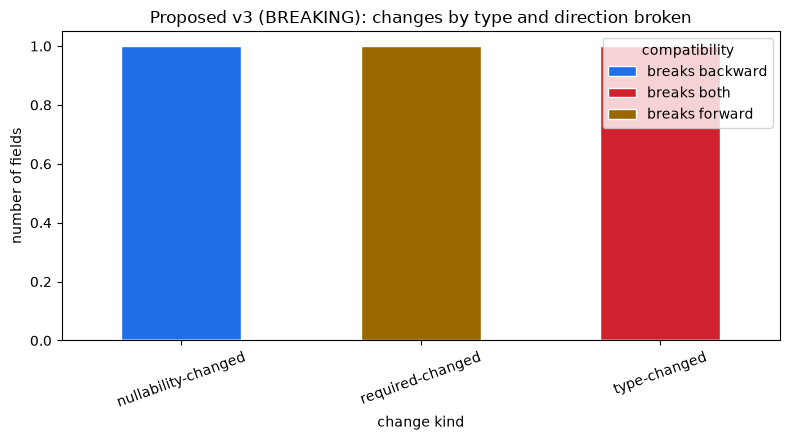

saved changes_by_type.png


In [7]:
cf = changes_frame(breaking['changes'])
cf = cf.copy()
cf['direction'] = cf.apply(
    lambda r: 'breaks both' if r.breaks_backward and r.breaks_forward
    else 'breaks backward' if r.breaks_backward
    else 'breaks forward' if r.breaks_forward
    else 'safe', axis=1)
pivot = cf.groupby(['kind', 'direction']).size().unstack(fill_value=0)

color_map = {'breaks both': '#cf222e', 'breaks backward': '#1f6feb',
             'breaks forward': '#9a6700', 'safe': '#1a7f37'}
colors = [color_map.get(c, '#57606a') for c in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white')
ax.set_title('Proposed v3 (BREAKING): changes by type and direction broken')
ax.set_xlabel('change kind')
ax.set_ylabel('number of fields')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='compatibility')
plt.tight_layout()
plt.savefig('changes_by_type.png', dpi=150)
plt.show()
print('saved changes_by_type.png')

<a id='summary'></a>
## 7. Summary
- A **schema is a contract** - a list of fields with a type, nullability, and whether a producer must supply it.
- The engine diffs a **proposed** schema against the **latest registered** version and classifies the verdict: **BACKWARD** (new consumers read old data), **FORWARD** (old consumers read new data), **FULL** (both), or **BREAKING** (neither).
- Each verdict is **explained by the specific field change** that drives it - a narrowed type, a field made required, a null forbidden.
- **Widening** a type (int -> long -> double) and adding an **optional** field are safe; **narrowing**, removing, or tightening nullability/required-ness break one or both directions.
- The rules are a **heuristic** - a human confirms intent before a breaking change ships.

<a id='tryit'></a>
## 8. Try your own schema
Uncomment and edit the proposed fields below, then re-run to see your own verdict.

In [8]:
# my_proposal = [
#     Field('event_id', 'long', nullable=False, required=True),
#     Field('user_id', 'long', nullable=False, required=True),
#     Field('amount', 'long', nullable=False, required=True),
#     Field('country', 'string', nullable=True, required=False),
#     Field('device', 'string', nullable=True, required=False),
#     # add / change / remove a field here...
# ]
# my_result = compare(reg.latest('customer_events'), Schema('customer_events', 3, my_proposal))
# print('VERDICT:', my_result['verdict'], '|', my_result['summary'])
# changes_frame(my_result['changes'])

---
Built by Phoebe Fu - Day 98 of the FDE portfolio. [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)